# Ride Price Estimation Project

Machine learning projects rarely start with a perfect dataset. In practice, ML engineers must decide what data to collect, which features matter, and how to structure raw information before modeling even begins.

In this project, we design a synthetic dataset and build an end-to-end ML solution for estimating ride prices.

**Learning Objectives:**
- Frame a real-world problem for ML
- Design a dataset with meaningful features
- Apply the full ML workflow
- Build and evaluate regression and classification models
- Communicate results using code and reasoning


## Problem Statement

Estimate the price of a ride based on trip and contextual factors.

**Tasks:**
1. Design the dataset
2. Clean and prepare the data
3. Train ML models
4. Evaluate and reflect on model behavior


## Dataset Design

**Features:**
- distance_km (numerical): Longer trips cost more
- trip_duration_min (numerical): Longer duration may increase price
- time_of_day (categorical): Peak hours may increase price
- traffic_level (categorical): Heavy traffic may increase price
- weather_condition (categorical): Bad weather may increase price
- demand_level (categorical): High demand can trigger surge pricing
- pickup_zone (categorical): Some zones may have higher base fares

**Target Variable:**
- ride_price (continuous)

**Excluded Feature Example:**
- Passenger age (irrelevant to price)


## 1. ML Mindset & Problem Framing

**Learning Problem:** Predict ride_price from trip and contextual features.

**Why ML instead of rules:** Price depends on multiple interacting factors. Fixed rules cannot capture complex interactions or adapt to new patterns. ML can learn these patterns from historical data.

**What the model learns:** 
- Regression: continuous price predictions
- Classification: probability of ride being high-cost


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

In [2]:
df = pd.read_csv('rides.csv')

In [3]:
df

,distance_km,trip_duration_min,time_of_day,traffic_level,weather_condition,demand_level,pickup_zone,ride_price
0,11.86,35.1,morning,medium,snowy,medium,airport,74.07
1,28.57,60.7,afternoon,high,rainy,medium,airport,152.02
2,22.23,49.8,morning,low,rainy,high,airport,112.61
3,18.36,61.5,morning,low,rainy,high,airport,115.95
4,5.52,16.1,afternoon,low,snowy,high,downtown,32.44
...,...,...,...,...,...,...,...,...
195,11.13,37.8,morning,low,rainy,high,airport,70.45
196,22.05,72.5,morning,high,clear,low,downtown,89.79
197,27.02,71.4,night,low,snowy,low,suburbs,86.72
198,26.73,83.6,night,high,snowy,low,suburbs,118.40


In [5]:
 # Data Exploration
print("Missing values:\n", df.isnull().sum())
print("\nUnique categorical values:")
for col in ['time_of_day','traffic_level','weather_condition','demand_level','pickup_zone']:
    print(f"{col}: {df[col].unique()}")
print("\nBasic statistics:\n", df.describe())

Missing values:
 distance_km          0
trip_duration_min    0
time_of_day          0
traffic_level        0
weather_condition    0
demand_level         0
pickup_zone          0
ride_price           0
dtype: int64

Unique categorical values:
time_of_day: ['morning' 'afternoon' 'night' 'evening']
traffic_level: ['medium' 'high' 'low']
weather_condition: ['snowy' 'rainy' 'clear']
demand_level: ['medium' 'high' 'low']
pickup_zone: ['airport' 'downtown' 'suburbs']

Basic statistics:
        distance_km  trip_duration_min  ride_price
count   200.000000         200.000000  200.000000
mean     15.036300          41.347500   70.619050
std       8.551856          24.267802   40.661578
min       1.160000           3.000000    7.730000
25%       7.632500          22.225000   37.667500
50%      15.340000          37.650000   68.950000
75%      22.947500          61.350000   98.620000
max      29.620000          92.600000  175.810000


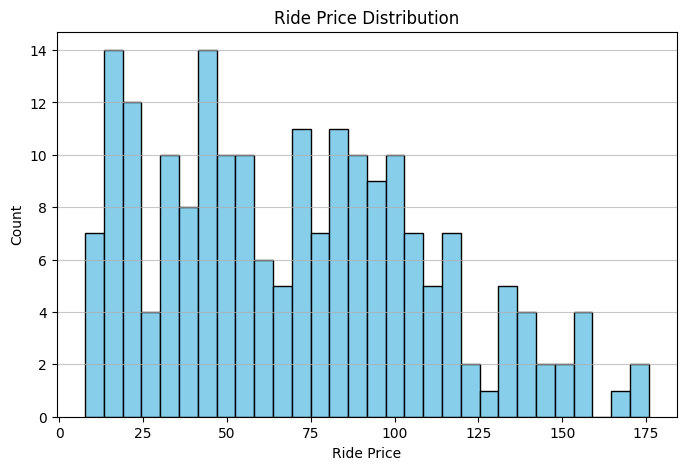

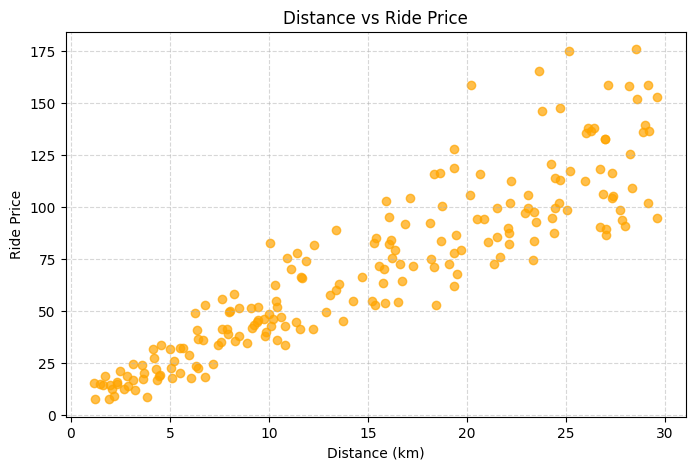

C:\Users\hp\AppData\Local\Temp\ipykernel_27172\2053053989.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=times)


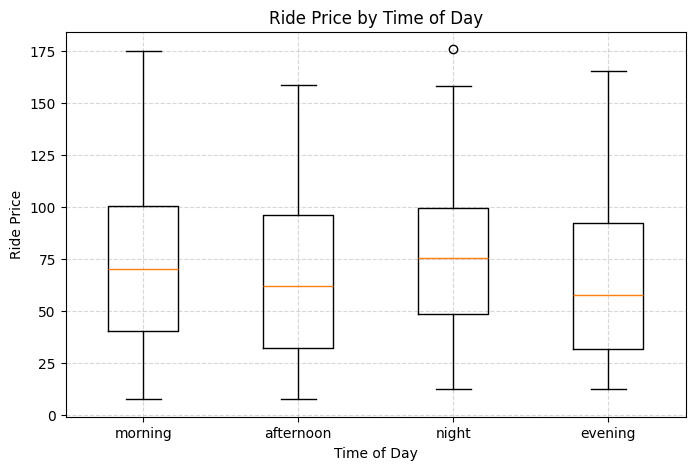

In [6]:
# Histogram
plt.figure(figsize=(8,5))
plt.hist(df['ride_price'], bins=30, edgecolor='black', color='skyblue')
plt.title("Ride Price Distribution")
plt.xlabel("Ride Price")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.7)
plt.show()

# Scatter: Distance vs Ride Price
plt.figure(figsize=(8,5))
plt.scatter(df['distance_km'], df['ride_price'], alpha=0.7, color='orange')
plt.title("Distance vs Ride Price")
plt.xlabel("Distance (km)")
plt.ylabel("Ride Price")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Boxplot: Ride Price by Time of Day
plt.figure(figsize=(8,5))
times = df['time_of_day'].unique()
data_to_plot = [df[df['time_of_day']==t]['ride_price'] for t in times]
plt.boxplot(data_to_plot, labels=times)
plt.title("Ride Price by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Ride Price")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [7]:
# Data Cleaning & Feature Engineering 
# Fill missing values
num_cols = ['distance_km', 'trip_duration_min']
cat_cols = ['time_of_day','traffic_level','weather_condition','demand_level','pickup_zone']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [8]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Scale numerical features
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Treat outliers: remove prices beyond 3 std devs
price_mean = df_encoded['ride_price'].mean()
price_std = df_encoded['ride_price'].std()
df_encoded = df_encoded[(df_encoded['ride_price'] >= price_mean - 3*price_std) &
                        (df_encoded['ride_price'] <= price_mean + 3*price_std)]

**Impact of Poor Data Quality:**  
Missing values, inconsistent labels, outliers, or unscaled features can mislead the model, reduce prediction accuracy, and cause poor generalization. Clean, consistent data is crucial for reliable ride price predictions.


In [9]:
# Regression Model
X = df_encoded.drop('ride_price', axis=1)
y = df_encoded['ride_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# Regression evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Linear Regression MSE: {mse:.2f}, R2: {r2:.2f}")

Linear Regression MSE: 91.94, R2: 0.94


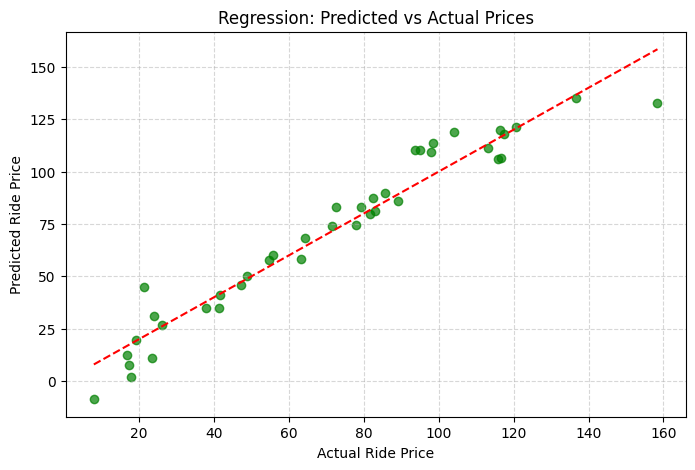

In [10]:
# Predicted vs Actual plot
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.7, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Regression: Predicted vs Actual Prices")
plt.xlabel("Actual Ride Price")
plt.ylabel("Predicted Ride Price")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [12]:
#  Classification Model: High-Cost Ride
median_price = df_encoded['ride_price'].median()
df_encoded['high_cost'] = (df_encoded['ride_price'] > median_price).astype(int)

X_cls = df_encoded.drop(['ride_price','high_cost'], axis=1)
y_cls = df_encoded['high_cost']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

logreg = LogisticRegression(max_iter=500)
logreg.fit(X_train_c, y_train_c)
y_pred_c = logreg.predict(X_test_c)
y_prob = logreg.predict_proba(X_test_c)[:,1]

In [13]:
# Classification evaluation
acc = accuracy_score(y_test_c, y_pred_c)
cm = confusion_matrix(y_test_c, y_pred_c)
print(f"Logistic Regression Accuracy: {acc:.2f}")
print("Confusion Matrix:\n", cm)

# Feature Importance (Regression) 
feature_importance = pd.Series(lr.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("\nTop 5 influential features (regression):\n", feature_importance.head())

Logistic Regression Accuracy: 0.93
Confusion Matrix:
 [[17  1]
 [ 2 20]]

Top 5 influential features (regression):
 demand_level_low      -22.266461
distance_km            20.343429
trip_duration_min      18.164164
pickup_zone_suburbs   -17.749423
traffic_level_low     -14.142278
dtype: float64


## Model Evaluation & Comparison

- Regression predicts continuous ride prices; classification predicts high/low cost.
- Data quality (missing values, outliers, inconsistent labels) affects both models.
- Most influential feature identified via regression coefficients.


## Ethical & Practical Reflection

- **Potential unfair pricing behavior:** Surge pricing may disadvantage riders in low-income areas.
- **Real-world deployment risk:** Incorrect predictions can reduce revenue or cause customer dissatisfaction.
- **Dataset limitation:** Synthetic data may not capture rare or extreme scenarios (e.g., special events, sudden demand spikes).
